<a href="https://colab.research.google.com/github/oyueo-mm/PAM_by_entry/blob/main/PAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_dist(p1, p2):
  # 유클리드 거리를 계산
  return np.sqrt(np.sum((p1 - p2)**2))

def compute_total_cost(data, medoid_indices):
  # 현재 메도이드 구성에서 총 비용과 레이블 계산
  n_samples = len(data)
  labels = np.zeros(n_samples, dtype=int)
  total_cost = 0

  for i in range(n_samples):
    # 현재 점과 모든 메도이드 사이의 거리 계산
    distances = [get_dist(data[i], data[m]) for m in medoid_indices]
    labels[i] = np.argmin(distances)
    total_cost += distances[labels[i]]

  return total_cost, labels

def pam(data, k, max_iter=100):
  n_samples = len(data)

  # 무작위로 초기 메도이드 선택
  current_medoids = np.random.choice(n_samples, k, replace=False)
  current_cost, labels = compute_total_cost(data, current_medoids)

  # 비용이 감소할 때까지 교체 반복
  for iteration in range(max_iter):
    improved = False
    for k_idx in range(k):
      for candidate_idx in range(n_samples): # 모든 메도이드가 아닌 객체와 교체 시도
        if candidate_idx in current_medoids:
            continue
        # 메도이드 후보 교체
        next_medoids = current_medoids.copy()
        next_medoids[k_idx] = candidate_idx
        next_cost, next_labels = compute_total_cost(data, next_medoids)
        if (next_cost - current_cost) < 0:
          current_cost = next_cost
          current_medoids = next_medoids
          labels = next_labels
          improved = True
          break # 현재 메도이드에 후보를 찾았으므로 다음으로
      if improved:
        break
    if not improved:
      break
  return current_medoids, labels, current_cost

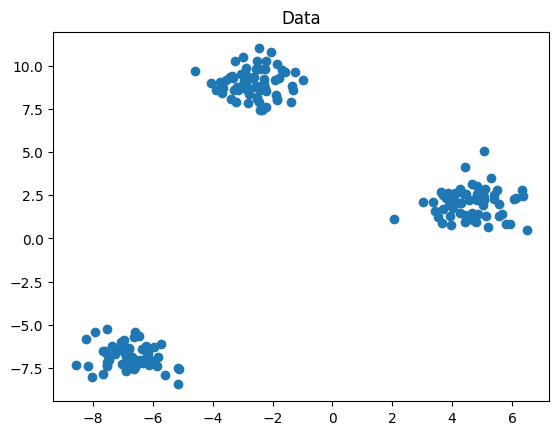

In [ ]:
from sklearn.datasets import make_blobs
X, _ = make_blobs(n_samples=200, centers=3, cluster_std=0.8, random_state=42)

plt.scatter(X[:, 0], X[:,1 ])
plt.title("Data")
plt.show()

In [ ]:
K = 3
final_medoids, final_labels, final_cost = pam(X, K)

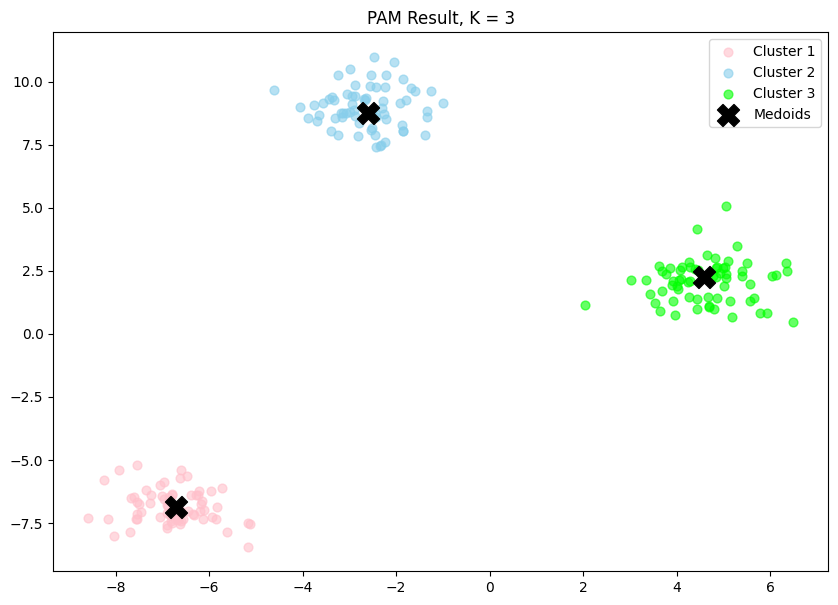

In [ ]:
plt.figure(figsize=(10, 7))

# 군집별 데이터 산점도
colors = ['pink', 'skyblue', 'lime']
for i in range(K):
    cluster_points = X[final_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],  c=colors[i], label=f'Cluster {i+1}', alpha=0.6, s=40)

# 최종 메도이드 표시 (검은색 X)
medoid_coords = X[final_medoids]
plt.scatter(medoid_coords[:, 0], medoid_coords[:, 1], c='black', marker='X', s=250, label='Medoids')
plt.title(f"PAM Result, K = {K}")
plt.legend()
plt.show()